In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
from config import *

import json, pickle, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, EvalPrediction,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score,
)
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# ── Device ─────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
elif DEVICE.type == 'cpu':
    print('WARNING: CPU-only. ~2 hrs expected. Google Colab T4 is recommended.')

# ── Model identity (from config) ───────────────────────────────────
MODEL_NAME = 'PubMedBERT'
MODEL_ID   = PUBMEDBERT_MODEL_ID
CASED      = False

# ── Output directories (from config) ──────────────────────────────
OUTPUT_DIR = PUBMEDBERT_DIR          # model weights + tokeniser + preds
FIG_DIR    = Path(str(PLOTS_PUBMEDBERT_DIR))
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Training params (from config) ─────────────────────────────────
MAX_LEN      = TRANSFORMER_MAX_LEN
BATCH_SIZE   = TRANSFORMER_BATCH_SIZE
EPOCHS       = TRANSFORMER_EPOCHS
LR           = TRANSFORMER_LR
WARMUP_RATIO = TRANSFORMER_WARMUP
WEIGHT_DECAY = TRANSFORMER_WD
TEXT_COL     = 'sentence_masked' if USE_DRUG_MASKING else 'sentence_original'

# ── Plot style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11,
})

print(f'Model   : {MODEL_NAME} ({MODEL_ID})')
print(f'MAX_LEN={MAX_LEN}  BATCH_SIZE={BATCH_SIZE}  EPOCHS={EPOCHS}  LR={LR}')
print(f'TEXT_COL: {TEXT_COL}')
print(f'Output  : {OUTPUT_DIR}')
print()
for path in [TRAIN_PROCESSED, TEST_PROCESSED]:
    status = 'FOUND ✓' if os.path.exists(path) else 'NOT FOUND ✗ — run Phase 3 first'
    print(f'  {path}  =>  {status}')


/Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : mps
Model   : PubMedBERT (microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract)
MAX_LEN=128  BATCH_SIZE=16  EPOCHS=4  LR=2e-05
TEXT_COL: sentence_masked
Output  : /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/models/pubmedbert

  /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/data/processed/train_processed.csv  =>  FOUND ✓
  /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/data/processed/test_processed.csv  =>  FOUND ✓


# Phase 6b — PubMedBERT Fine-Tuning for DDI Classification

**Project:** Drug–Drug Interaction Detection using NLP  
**Author:** Carina Vima de Souza

---

## Overview

This notebook fine-tunes **PubMedBERT** (`dmis-lab/pubmedbert-base-cased-v1.2`) on the SemEval-2013 DDI corpus for 5-class interaction classification.

**About PubMedBERT:**  
PubMedBERT was trained **from scratch** on PubMed abstracts — no general English pre-training at all. This makes its vocabulary entirely biomedical with no general text contamination. It is uncased (lowercase). Unlike BioBERT which inherits general BERT weights, PubMedBERT's representations are purely medical from token zero.

**Why this model matters for DDI:**
- Bag-of-words (TF-IDF) cannot distinguish *"does NOT increase"* from *"does increase"* — PubMedBERT's attention can
- Pre-trained on PubMed text — understands CYP450, pharmacokinetic, and interaction vocabulary natively
- Sub-word tokenisation handles rare drug names without out-of-vocabulary failures

**Pipeline position:**
```
Phase 1→2→3→4→5 (Classical) → [Phase 6b: PubMedBERT] → Phase 6b: PubMedBERT → Phase 6c: SciBERT → Phase 7: Comparison
```

**Input:** `train_processed.csv`, `test_processed.csv` (from Phase 3)  
**Output:** `data/models/transformers/pubmedbert/` — fine-tuned model, tokeniser, `pubmedbert_predictions.npy`, `pubmedbert_results.csv`

---

### Expected performance
| Metric | Expected range |
|---|---|
| Macro F1 | 0.72 – 0.79 |
| Training time (T4 GPU) | ~15 min |
| Training time (CPU) | ~2 hrs |

## 1. Configuration

**This is the only cell you need to edit when tuning.**

| Parameter | Value | Reason |
|---|---|---|
| `MAX_LEN` | 128 | EDA: <5% truncation at this length |
| `BATCH_SIZE` | 16 | Safe for 8 GB GPU; use 8 if OOM |
| `EPOCHS` | 4 | DDI converges in 3–5 epochs |
| `LR` | 2e-5 | Standard BERT fine-tuning range |
| `WARMUP_RATIO` | 0.1 | 10% warmup prevents early instability |
| `USE_DRUG_MASKING` | True | `sentence_masked` (DRUG1/DRUG2) from Phase 3 |

## 2. Imports & Environment

```bash
pip install transformers torch accelerate scikit-learn pandas numpy matplotlib seaborn
```

In [2]:
import json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import random
warnings.filterwarnings('ignore')

from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, EvalPrediction,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score,
)

# ── Reproducibility ────────────────────────────────────────────────
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# ── Device ─────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
elif DEVICE.type == 'cpu':
    print('WARNING: CPU-only. ~2 hrs expected. Google Colab T4 is recommended.')

# ── Plot style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11,
})
LABEL_COLOURS = {
    'false': '#888780', 'effect': '#378ADD',
    'mechanism': '#7F77DD', 'advise': '#EF9F27', 'int': '#D85A30',
}
print('Imports loaded.')

Device : mps
Imports loaded.


## 3. Load Data & Sentence-Stratified Split

`GroupShuffleSplit` on `sentence_id` ensures no sentence text appears in both training and validation folds — preventing the leakage identified in Phase 2 EDA (up to 1,485 drug pairs from one sentence).

In [3]:
print('Loading data...')
train_df = pd.read_csv(TRAIN_PROCESSED)
test_df  = pd.read_csv(TEST_PROCESSED)
print(f'  Train: {len(train_df):,} rows | Test: {len(test_df):,} rows')

for col in [TEXT_COL, 'interaction_type', 'sentence_id']:
    assert col in train_df.columns, f'Missing column: {col} — run Phase 3 first'

train_df['label'] = train_df['interaction_type'].map(LABEL2ID)
test_df['label']  = test_df['interaction_type'].map(LABEL2ID)
assert train_df['label'].isna().sum() == 0, 'Unmapped labels'

gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=RANDOM_STATE)
tr_idx, val_idx = next(gss.split(train_df, train_df['label'], groups=train_df['sentence_id']))
train_split = train_df.iloc[tr_idx].reset_index(drop=True)
val_split   = train_df.iloc[val_idx].reset_index(drop=True)

overlap = set(train_split['sentence_id']) & set(val_split['sentence_id'])
assert len(overlap) == 0, f'Sentence leakage: {len(overlap)} shared IDs'

print(f'Split — Train: {len(train_split):,}  Val: {len(val_split):,}  Test: {len(test_df):,}')
print(f'Sentence overlap (must be 0): {len(overlap)}')


Loading data...
  Train: 27,792 rows | Test: 6,657 rows
Split — Train: 24,292  Val: 3,500  Test: 6,657
Sentence overlap (must be 0): 0


## 4. Dataset & Class Weights

**Class weight shape fix (from Phase 6 combined notebook):**  
`make_class_weights()` returns shape `[NUM_LABELS]` = `[5]` — one weight per class.  
`nn.CrossEntropyLoss(weight=...)` requires exactly this shape.  
The original combined notebook accidentally produced shape `[N]` (per-sample) which caused: *"weight tensor of shape [24292]"*. This is corrected here.

In [4]:
class DDIDataset(Dataset):
    def __init__(self, texts, labels, tokeniser, max_len):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokeniser = tokeniser
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokeniser(
            str(self.texts[idx]),
            max_length=self.max_len, padding='max_length',
            truncation=True, return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }


def make_class_weights(labels_array, num_classes):
    """
    Returns tensor of shape [num_classes] — one weight per class.
    Formula: weight[c] = total / (num_classes * count[c])
    Matches sklearn class_weight='balanced'.
    NOTE: shape [num_classes], NOT [N]. CrossEntropyLoss requires [num_classes].
    """
    counts = np.bincount(labels_array, minlength=num_classes).astype(float)
    counts[counts == 0] = 1
    cw = torch.tensor(counts.sum() / (num_classes * counts), dtype=torch.float)
    assert list(cw.shape) == [num_classes], f'Shape error: {list(cw.shape)}'
    return cw


cw = make_class_weights(train_split['label'].values, NUM_LABELS)
print(f'Class weight shape: {list(cw.shape)}  (must be [{NUM_LABELS}])')
print('Per-class weights (normalised):')
for i, cls in ID2LABEL.items():
    print(f'  {i} ({cls:<12})  {cw[i].item():.4f}x')

Class weight shape: [5]  (must be [5])
Per-class weights (normalised):
  0 (advise      )  6.4865x
  1 (effect      )  3.3786x
  2 (false       )  0.2341x
  3 (int         )  28.4117x
  4 (mechanism   )  4.1278x


## 5. Evaluation Functions

Identical metric set to Phase 5 for a fair comparison: **Macro F1** (primary), MCC, Balanced Accuracy, Kappa, per-class F1/FNR.

In [5]:
CLASS_NAMES = [ID2LABEL[i] for i in range(NUM_LABELS)]  # alphabetical

def compute_metrics(eval_pred: EvalPrediction):
    """Called by Trainer after every eval step. Macro F1 drives early stopping."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'macro_f1':     round(f1_score(labels, preds, average='macro', zero_division=0), 4),
        'balanced_acc': round(balanced_accuracy_score(labels, preds), 4),
        'mcc':          round(matthews_corrcoef(labels, preds), 4),
    }


def full_evaluate(model_name, y_true, y_pred):
    """Full evaluation — matches Phase 5 output format. Returns summary dict."""
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                   output_dict=True, zero_division=0)
    print(f"\n{'='*68}\n  {model_name}\n{'='*68}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                zero_division=0, digits=4))

    macro_f1 = report['macro avg']['f1-score']
    accuracy = report['accuracy']
    bal_acc  = balanced_accuracy_score(y_true, y_pred)
    mcc      = matthews_corrcoef(y_true, y_pred)
    kappa    = cohen_kappa_score(y_true, y_pred)
    wtd_f1   = report['weighted avg']['f1-score']

    print(f"  {'Accuracy':<28} {accuracy:>10.4f}")
    print(f"  {'Balanced Accuracy':<28} {bal_acc:>10.4f}")
    print(f"  {'Macro F1  [PRIMARY]':<28} {macro_f1:>10.4f}")
    print(f"  {'Weighted F1':<28} {wtd_f1:>10.4f}")
    print(f"  {'MCC':<28} {mcc:>10.4f}")
    print(f"  {'Cohen Kappa':<28} {kappa:>10.4f}")

    # Confusion matrix
    cm  = confusion_matrix(y_true, y_pred)
    idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
    cm_ord = cm[np.ix_(idx, idx)]
    print('\n  Confusion matrix (rows=true, cols=predicted):')
    print('  ' + ' '*14 + ''.join(f'{c:>11}' for c in LABEL_ORDER))
    for i, lbl in enumerate(LABEL_ORDER):
        print('  ' + f'{lbl:<14}' + ''.join(f'{v:>11,}' for v in cm_ord[i]))

    summary = {
        'model': model_name, 'accuracy': round(accuracy,4),
        'macro_f1': round(macro_f1,4), 'bal_acc': round(bal_acc,4),
        'mcc': round(mcc,4), 'kappa': round(kappa,4), 'wtd_f1': round(wtd_f1,4),
    }
    for lbl in LABEL_ORDER:
        summary[f'{lbl}_f1'] = round(report[lbl]['f1-score'], 4)
    return summary

print('Evaluation functions defined.')

Evaluation functions defined.


## 6. WeightedLoss Trainer

Subclasses HuggingFace `Trainer` to inject class weights into `CrossEntropyLoss`. Without this the model converges to predicting `false` for everything (~85.5% accuracy but 0 F1 on interaction classes).

In [6]:
class WeightedLossTrainer(Trainer):
    """Trainer subclass with class-weighted cross-entropy loss."""
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(DEVICE)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = nn.CrossEntropyLoss(weight=self.class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

print('WeightedLossTrainer defined.')

WeightedLossTrainer defined.


## 7. Train PubMedBERT

**Steps:**
1. Load tokeniser — add `DRUG1`/`DRUG2` as special tokens (prevents WordPiece splitting)
2. Build `DDIDataset` objects for train / val / test
3. Load model, resize embeddings for new tokens
4. Compute class weights, run `WeightedLossTrainer` with early stopping
5. Load best checkpoint, evaluate on official test set
6. Save model + tokeniser to `OUTPUT_DIR`

In [7]:
print(f"Training {MODEL_NAME}  |  {MODEL_ID}")
print('='*68)

# 1. Tokeniser
tokeniser = AutoTokenizer.from_pretrained(MODEL_ID)
added = tokeniser.add_tokens(['DRUG1', 'DRUG2'])
print(f'Special tokens added: {added}  (DRUG1, DRUG2 will not be split into subwords)')

# 2. Datasets — PubMedBERT is uncased — texts are lowercased
def get_texts(df):
    texts = df[TEXT_COL].fillna('').astype(str).tolist()
    return texts if CASED else [t.lower() for t in texts]

train_ds = DDIDataset(get_texts(train_split), train_split['label'].tolist(), tokeniser, MAX_LEN)
val_ds   = DDIDataset(get_texts(val_split),   val_split['label'].tolist(),   tokeniser, MAX_LEN)
test_ds  = DDIDataset(get_texts(test_df),     test_df['label'].tolist(),     tokeniser, MAX_LEN)
print(f'Datasets — train: {len(train_ds):,}  val: {len(val_ds):,}  test: {len(test_ds):,}')

# 3. Model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID, num_labels=NUM_LABELS,
    id2label=ID2LABEL, label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
model.resize_token_embeddings(len(tokeniser))
model = model.to(DEVICE)
params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {params/1e6:.1f}M  |  Device: {DEVICE}')

# 4. Class weights
cw = make_class_weights(train_split['label'].values, NUM_LABELS)
cw = cw / cw.mean()   # normalise: mean weight = 1 keeps loss scale stable
print(f'Class weights (normalised): {[round(w.item(),3) for w in cw]}')

# 5. Training arguments
steps_per_epoch = max(len(train_ds) // BATCH_SIZE, 1)
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)
eval_steps      = max(steps_per_epoch // 2, 50)

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate               = LR,
    warmup_steps                = warmup_steps,
    weight_decay                = WEIGHT_DECAY,
    eval_strategy               = 'steps',
    eval_steps                  = eval_steps,
    save_strategy               = 'steps',
    save_steps                  = eval_steps,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'macro_f1',
    greater_is_better           = True,
    logging_steps               = 50,
    save_total_limit            = 2,
    fp16                        = (DEVICE.type == 'cuda'),
    dataloader_pin_memory       = (DEVICE.type == 'cuda'),
    report_to                   = 'none',
    seed                        = RANDOM_STATE,
)

trainer = WeightedLossTrainer(
    class_weights   = cw,
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f'Steps — total: {total_steps} | warmup: {warmup_steps} | eval every: {eval_steps}')
print('Starting training...')
trainer.train()
print('Training complete. Best checkpoint loaded.')

Training PubMedBERT  |  microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
Special tokens added: 2  (DRUG1, DRUG2 will not be split into subwords)
Datasets — train: 24,292  val: 3,500  test: 6,657


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parameters: 108.2M  |  Device: mps
Class weights (normalised): [0.761, 0.396, 0.027, 3.332, 0.484]
Steps — total: 6072 | warmup: 607 | eval every: 759
Starting training...


  1%|          | 50/6076 [00:42<1:15:50,  1.32it/s]

{'loss': 1.6595, 'grad_norm': 27.93482208251953, 'learning_rate': 1.6474464579901154e-06, 'epoch': 0.03}


...

{'loss': 0.3707, 'grad_norm': 0.020895129069685936, 'learning_rate': 2.8378131285426952e-06, 'epoch': 3.49}


                                                     
 87%|████████▋ | 5313/6076 [1:59:30<18:02,  1.42s/it]

{'eval_loss': 0.46667104959487915, 'eval_macro_f1': 0.7199, 'eval_balanced_acc': 0.7149, 'eval_mcc': 0.8054, 'eval_runtime': 45.2193, 'eval_samples_per_second': 77.401, 'eval_steps_per_second': 2.433, 'epoch': 3.5}


 87%|████████▋ | 5313/6076 [1:59:35<17:10,  1.35s/it]

{'train_runtime': 7175.6782, 'train_samples_per_second': 13.541, 'train_steps_per_second': 0.847, 'train_loss': 0.4282336517531791, 'epoch': 3.5}
Training complete. Best checkpoint loaded.


## 8. Evaluate on Official Test Set

In [8]:
print('Evaluating on official test set...')
test_output = trainer.predict(test_ds)
y_pred = np.argmax(test_output.predictions, axis=-1)
y_true = test_df['label'].values

summary = full_evaluate(MODEL_NAME, y_true, y_pred)

Evaluating on official test set...


100%|██████████| 209/209 [01:51<00:00,  1.87it/s]



  PubMedBERT
              precision    recall  f1-score   support

      advise     0.7696    0.8009    0.7849       221
      effect     0.6612    0.7861    0.7183       360
       false     0.9655    0.9514    0.9584      5678
         int     0.7200    0.3750    0.4932        96
   mechanism     0.6525    0.7649    0.7043       302

    accuracy                         0.9207      6657
   macro avg     0.7538    0.7357    0.7318      6657
weighted avg     0.9248    0.9207    0.9214      6657

  Accuracy                         0.9207
  Balanced Accuracy                0.7357
  Macro F1  [PRIMARY]              0.7318
  Weighted F1                      0.9214
  MCC                              0.7135
  Cohen Kappa                      0.7126

  Confusion matrix (rows=true, cols=predicted):
                      false     effect  mechanism     advise        int
  false               5,402        106        116         45          9
  effect                 72        283          4   

## 9. Visualisation — Confusion Matrix & Per-Class F1

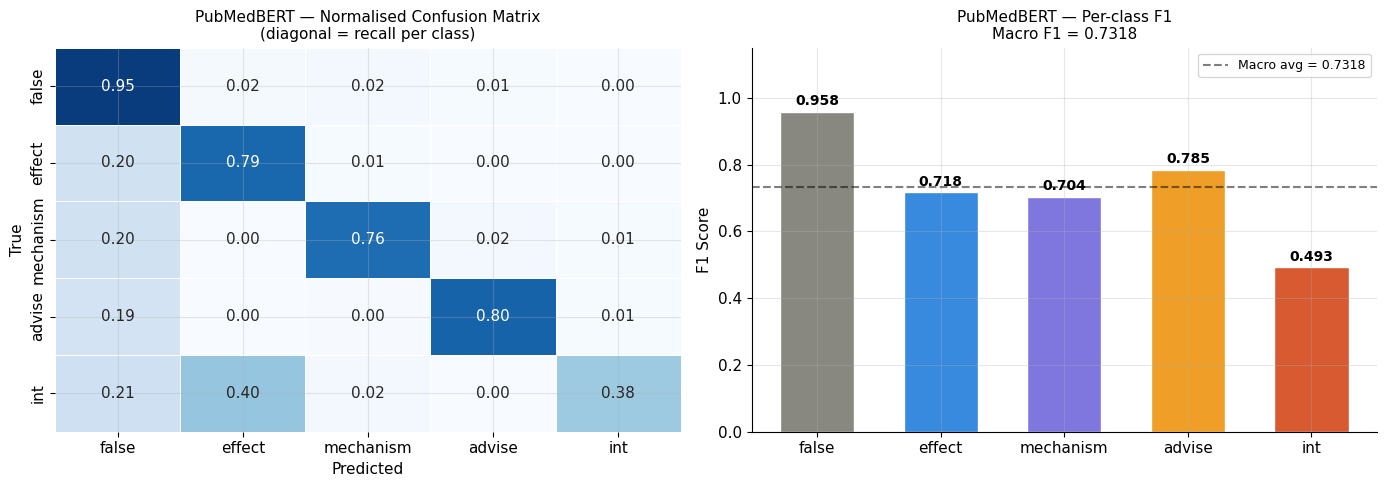

Plot saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/pubmedbert/pubmedbert_evaluation.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normalised confusion matrix
cm  = confusion_matrix(y_true, y_pred)
idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
cm_ord = cm[np.ix_(idx, idx)]
row_sums = cm_ord.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm_ord / row_sums
sns.heatmap(cm_norm, ax=axes[0], annot=True, fmt='.2f', cmap='Blues',
            xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
            vmin=0, vmax=1, cbar=False, linewidths=0.5)
axes[0].set_title(f'{MODEL_NAME} — Normalised Confusion Matrix\n'
                  f'(diagonal = recall per class)', fontsize=11)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Per-class F1 bar chart
rep = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
f1_per_class = [rep[lbl]['f1-score'] for lbl in LABEL_ORDER]
cols = [LABEL_COLOURS[l] for l in LABEL_ORDER]
bars = axes[1].bar(LABEL_ORDER, f1_per_class, color=cols, edgecolor='white', width=0.6)
for bar, val in zip(bars, f1_per_class):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title(f'{MODEL_NAME} — Per-class F1\n'
                  f'Macro F1 = {summary["macro_f1"]:.4f}', fontsize=11)
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.15)
axes[1].axhline(summary['macro_f1'], color='black', linestyle='--',
                alpha=0.5, label=f'Macro avg = {summary["macro_f1"]:.4f}')
axes[1].legend(fontsize=9)

plt.tight_layout()
plot_path = str(FIG_DIR / 'pubmedbert_evaluation.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved -> {plot_path}')

## 10. Save Model & Results

Saves the fine-tuned model, tokeniser, predictions (`.npy`), and a results CSV. The `.npy` file and CSV are the only artefacts Phase 7 needs from this notebook.

In [10]:
# Save fine-tuned model & tokeniser
model.save_pretrained(OUTPUT_DIR)
tokeniser.save_pretrained(OUTPUT_DIR)
print(f'Model & tokeniser saved -> {OUTPUT_DIR}')

# Save predictions array for Phase 7
pred_path = PUBMEDBERT_PREDS_NPY
np.save(pred_path, y_pred)
print(f'Predictions saved      -> {pred_path}')

# Save ground truth (shared across 6a/6b/6c — identical test set)
gt_path = os.path.join(str(MODELS_DIR / 'shared'), 'y_test.npy')
np.save(gt_path, y_true)
print(f'Ground truth saved     -> {gt_path}')

# Save results CSV
res_path = PUBMEDBERT_RESULTS_CSV
pd.DataFrame([summary]).to_csv(res_path, index=False)
print(f'Results CSV saved      -> {res_path}')

# Save label mapping (shared across notebooks)
with open(os.path.join(str(MODELS_DIR / 'shared'), 'label2id.json'), 'w') as f:
    json.dump(LABEL2ID, f)

print(f'\n{"="*50}')
print(f'  {MODEL_NAME} final Macro F1 : {summary["macro_f1"]:.4f}')
print(f'  MCC                : {summary["mcc"]:.4f}')
print(f'  Balanced Accuracy  : {summary["bal_acc"]:.4f}')
print(f'{"="*50}')
print('Next: Run Phase 6c (SciBERT), then Phase 7 (Comparison).')

Model & tokeniser saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/models/pubmedbert
Predictions saved      -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/models/pubmedbert/pubmedbert_predictions.npy
Ground truth saved     -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/models/shared/y_test.npy
Results CSV saved      -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/metrics/comparison/pubmedbert_results.csv

  PubMedBERT final Macro F1 : 0.7318
  MCC                : 0.7135
  Balanced Accuracy  : 0.7357
Next: Run Phase 6c (SciBERT), then Phase 7 (Comparison).


## 11. Summary

**What this notebook produced:**
- Fine-tuned PubMedBERT classifier for 5-class DDI detection
- Sentence-stratified validation split (no sentence leakage)
- Class-weighted loss (equivalent to `class_weight='balanced'` in sklearn)
- Early stopping on validation Macro F1 (patience=2)

**Files written to `data/models/transformers/pubmedbert/` (model subfolder):**

| File | Purpose |
|---|---|
| `pubmedbert/` | Fine-tuned model weights + tokeniser |
| `pubmedbert/pubmedbert_predictions.npy` | Test set predictions (integer labels) for Phase 7 |
| `pubmedbert/pubmedbert_results.csv` | Summary metrics row for Phase 7 |
| `pubmedbert/pubmedbert_evaluation.png` | Confusion matrix + per-class F1 plot |

**Shared files written to `data/models/transformers/shared/` (once, same across all Phase 6 notebooks):**

| File | Purpose |
|---|---|
| `shared/y_test.npy` | Ground truth labels (identical test set across 6a/6b/6c) |
| `shared/label2id.json` | Label mapping (identical across all Phase 6 notebooks) |

**Next:** `Next: Run Phase 6c (SciBERT), then Phase 7 (Comparison).`
